saved the GIF


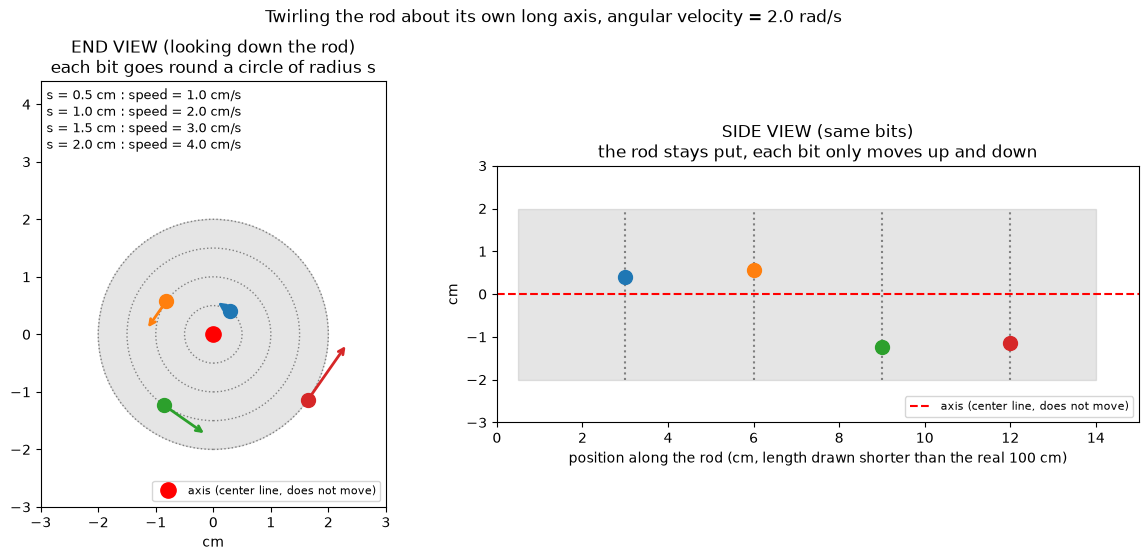

In [1]:
import os
import numpy as np  # type: ignore
import matplotlib.pyplot as plt  # type: ignore
from matplotlib.animation import FuncAnimation, PillowWriter  # type: ignore
from matplotlib.patches import Circle, Rectangle  # type: ignore
from datetime import datetime

RESULT_DIR = os.path.join(os.getcwd(), "result")
os.makedirs(RESULT_DIR, exist_ok=True)
TIMESTAMP = datetime.now().strftime("%Y%m%d_%H%M%S")

# ─────────────────────────────────────────────
# STEP 1: The twirl, seen two ways at once
#
# What we have: a rod of radius R = 2 cm that twirls about its own long axis at a constant angular velocity W.
# What we want: to SEE what is moving and what is not.
#
# Four marked bits of material sit at different distances s from the center line.
#   left panel:  END VIEW, looking down the axis. Each bit goes round a circle of radius s.
#   right panel: SIDE VIEW of the same bits. Each bit only moves UP and DOWN, y = s sin(angle).
#                The rod itself does not move sideways at all.
# The length of the rod is drawn shorter than 1 m so the picture is readable (not to scale).
#
# speed of a bit:  v = s x W   (cm/s)  (the same rule as before, v = r w)
# ─────────────────────────────────────────────

ROD_RADIUS_CM = 2.0  # cm, foundational (0.02 m)
ANGULAR_VELOCITY = 2.0  # rad/s, foundational, a drawing choice
DURATION = 3.2  # s, about one full turn (2 pi / 2 rad/s = 3.14 s)
FPS = 25  # foundational (a drawing choice)
ARROW_SCALE = 0.3  # drawing scale: 1 cm/s of speed is drawn as an arrow 0.3 cm long

distances_cm = np.array([0.5, 1.0, 1.5, 2.0])  # cm, distance s of each marked bit from the center line
start_angles = np.deg2rad([0, 90, 180, 270])  # rad, where each bit starts on its circle
bit_colors = ["C0", "C1", "C2", "C3"]
side_x_positions = np.array([3.0, 6.0, 9.0, 12.0])  # cm, where along the (shortened) rod each bit sits, side view only

time_log = np.arange(0, DURATION, 1 / FPS)  # s

fig, (ax_end, ax_side) = plt.subplots(1, 2, figsize=(12, 5.6), gridspec_kw={"width_ratios": [1, 1.5]})

# END VIEW (left)
ax_end.set_xlim(-3, 3)
ax_end.set_ylim(-3, 4.4)  # extra room at the top for the speed labels
ax_end.set_aspect("equal")
ax_end.add_patch(Circle((0, 0), ROD_RADIUS_CM, color="gray", alpha=0.2))
for s in distances_cm:
    ax_end.add_patch(Circle((0, 0), s, fill=False, linestyle=":", color="gray"))
ax_end.plot([0], [0], "o", color="red", markersize=11, zorder=5, label="axis (center line, does not move)")
ax_end.set_title("END VIEW (looking down the rod)\neach bit goes round a circle of radius s")
ax_end.set_xlabel("cm")
ax_end.legend(loc="lower right", fontsize=8)
end_dots = [ax_end.plot([], [], "o", color=c, markersize=10, zorder=6)[0] for c in bit_colors]
end_arrows = []
end_text = ax_end.text(-2.9, 4.3, "", fontsize=9, va="top")

# SIDE VIEW (right)
ax_side.set_xlim(0, 15)
ax_side.set_ylim(-3, 3)
ax_side.set_aspect("equal")
ax_side.add_patch(Rectangle((0.5, -ROD_RADIUS_CM), 13.5, 2 * ROD_RADIUS_CM, color="gray", alpha=0.2))
ax_side.axhline(0, color="red", linestyle="--", linewidth=1.5, label="axis (center line, does not move)")
for x_pos in side_x_positions:
    ax_side.plot([x_pos, x_pos], [-ROD_RADIUS_CM, ROD_RADIUS_CM], ":", color="gray")
ax_side.set_title("SIDE VIEW (same bits)\nthe rod stays put, each bit only moves up and down")
ax_side.set_xlabel("position along the rod (cm, length drawn shorter than the real 100 cm)")
ax_side.set_ylabel("cm")
ax_side.legend(loc="lower right", fontsize=8)
side_dots = [ax_side.plot([], [], "o", color=c, markersize=10, zorder=6)[0] for c in bit_colors]

fig.suptitle(f"Twirling the rod about its own long axis, angular velocity = {ANGULAR_VELOCITY} rad/s")


def update(frame_index):
    t = time_log[frame_index]
    angles = start_angles + ANGULAR_VELOCITY * t  # rad
    for old in end_arrows:
        old.remove()
    end_arrows.clear()
    lines = []
    for k, (s, angle) in enumerate(zip(distances_cm, angles)):
        position = s * np.array([np.cos(angle), np.sin(angle)])  # cm, end view
        tangent = np.array([-np.sin(angle), np.cos(angle)])  # unit vector along the circle
        speed = ANGULAR_VELOCITY * s  # cm/s, v = s w
        tip = position + ARROW_SCALE * speed * tangent
        end_dots[k].set_data([position[0]], [position[1]])
        end_arrows.append(ax_end.annotate("", xy=tip, xytext=position, arrowprops=dict(arrowstyle="->", color=bit_colors[k], lw=2)))
        side_dots[k].set_data([side_x_positions[k]], [s * np.sin(angle)])
        lines.append(f"s = {s:.1f} cm : speed = {speed:.1f} cm/s")
    end_text.set_text("\n".join(lines))
    return end_dots + side_dots


fig.tight_layout()
animation = FuncAnimation(fig, update, frames=len(time_log), interval=1000 / FPS, blit=False)
animation.save(os.path.join(RESULT_DIR, f"rod_twirl_long_axis_{TIMESTAMP}.gif"), writer=PillowWriter(fps=FPS))
print("saved the GIF")

update(int(0.5 / (1 / FPS)))  # one still frame at t = 0.5 s
fig.savefig(os.path.join(RESULT_DIR, f"rod_twirl_long_axis_still_{TIMESTAMP}.png"))
plt.show()